Final parameters:
Intercept: 6.772915671135683
Slope: 4.227427234491568
Final loss: 0.36020097466421375


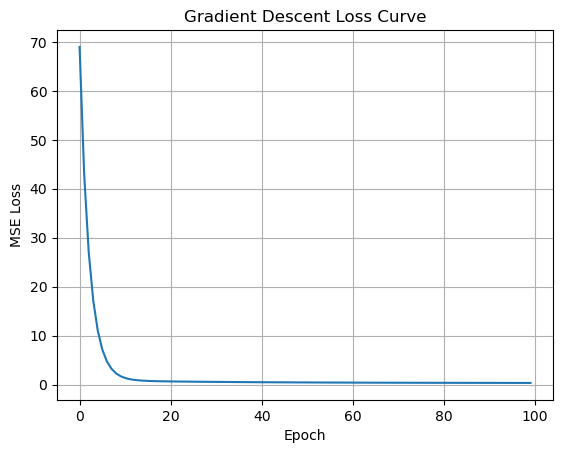

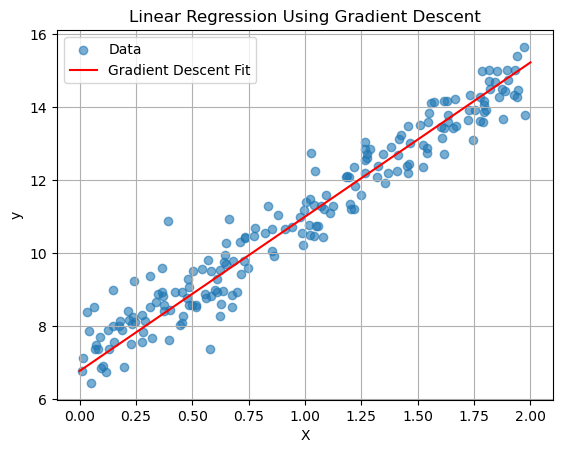

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate sample data: y = 4x + 7 + noise
np.random.seed(42)

X = 2 * np.random.rand(200, 1)
y = 4 * X + 7 + np.random.randn(200, 1) * 0.6

# Add bias column: X_b = [1, x]
X_b = np.c_[np.ones((X.shape[0], 1)), X]


def predict(X, theta):
    return X @ theta


def mse_loss(X, y, theta):
    m = len(y)
    error = predict(X, theta) - y
    return (1 / m) * np.sum(error ** 2)


def compute_gradient(X, y, theta):
    m = len(y)
    error = predict(X, theta) - y
    gradient = (2 / m) * X.T @ error
    return gradient


def gradient_descent(X, y, learning_rate=0.05, epochs=100):
    m, n = X.shape
    theta = np.random.randn(n, 1)
    losses = []

    for epoch in range(epochs):
        grad = compute_gradient(X, y, theta)
        theta = theta - learning_rate * grad

        loss = mse_loss(X, y, theta)
        losses.append(loss)

    return theta, losses


theta, losses = gradient_descent(
    X_b,
    y,
    learning_rate=0.05,
    epochs=100
)

print("Final parameters:")
print("Intercept:", theta[0][0])
print("Slope:", theta[1][0])
print("Final loss:", losses[-1])


# Plot loss curve
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Gradient Descent Loss Curve")
plt.grid(True)
plt.show()


# Plot regression line
x_line = np.linspace(0, 2, 100).reshape(-1, 1)
x_line_b = np.c_[np.ones((x_line.shape[0], 1)), x_line]
y_pred = x_line_b @ theta

plt.scatter(X, y, alpha=0.6, label="Data")
plt.plot(x_line, y_pred, color="red", label="Gradient Descent Fit")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression Using Gradient Descent")
plt.legend()
plt.grid(True)
plt.show()